# 비모수적 개별 처치 효과(CATE) 추정

- 목표: 두 개의 다른 데이터셋(아이스크림, 이메일)을 사용하여, CATE(개별 처치 효과) 추정 시 선형 모델(OLS)와 비모수적 메타-러너(S/T/X-Learner) 비교.
- 데이터 1 (연속형 T):
    - 학습: ice_cream_sales.csv (편향된 관측 데이터)
    - 평가: ice_cream_sales_rnd.csv (무작위 RCT 데이터)
- 데이터 2 (이진형 T):
    - 학습: invest_email_biased.csv (편향된 관측 데이터)
    - 평가: invest_email_rnd.csv (무작위 RCT 데이터)
- 평가 지표:
    - 수치: AUUC (Area Under Uplift Curve) - 높을수록 우수함.
    - 시각화: 누적 성과 곡선 (Cumulative Gain Plot) - 베이스라인(무작위)보다 높아야 함.

## 1. 라이브러리 및 헬퍼 함수

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Callable

# 시각화 스타일 설정
plt.style.use('ggplot')
sns.set_palette('colorblind')

In [16]:
# --- 헬퍼 함수 (연속형 처치용) ---
def sensitivity(data, y, t):
    """
    (연속형 T용) 단일 변수 선형 회귀의 기울기(민감도)를 계산합니다.
    """
    return (np.sum((data[t] - data[t].mean()) * (data[y] - data[y].mean())) /
            np.sum((data[t] - data[t].mean())**2))

def cumulative_gain_continuous(dataset, prediction, y, t, min_periods=30, steps=100):
    """
    (연속형 T용) 누적 성과 곡선(Cumulative Gain)을 계산합니다.
    
    """
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(min_periods, size, size // steps)) + [size]
    
    # (rows/size)로 정규화합니다.
    return np.array([sensitivity(ordered_df.head(rows), y, t) * (rows / size) for rows in n_rows])

def auuc_score_continuous(data, cate, y, t, min_periods=30, steps=100):
    """(연속형 T용) AUUC 점수를 계산합니다."""
    model_gain = cumulative_gain_continuous(data, cate, y, t, min_periods, steps)
    
    # 베이스라인 (전체 데이터의 평균 민감도 * 비율)
    baseline_sens = sensitivity(data, y, t)
    baseline_gain = np.linspace(0, 1, len(model_gain)) * baseline_sens * (len(data) / (len(data) - min_periods + 1)) # 스케일 조정
    
    # 모델 성과 - 베이스라인 성과의 면적
    auuc = (model_gain - baseline_gain).sum() / len(model_gain)
    return auuc

# --- 헬퍼 함수 (이진형 처치용) ---
def elast(data, y, t):
    """(이진형 T용) ATE(평균 효과)를 계산합니다."""
    ate = (data.query(f"{t}==1")[y].mean() -
           data.query(f"{t}==0")[y].mean())
    return ate

def cumulative_gain_binary(data, cate, y, t, min_rows=30, steps=100):
    """(이진형 T용) 누적 성과 곡선(Uplift Curve)을 계산합니다."""
    data = data.copy()
    data["cate"] = data[cate]
    data = data.sort_values("cate", ascending=False)
    
    thresholds = np.linspace(0, 100, steps + 1)[1:]
    
    gains = []
    for threshold in thresholds:
        n_rows = int(len(data) * (threshold / 100))
        if n_rows < min_rows:
            continue
        
        quant_data = data.head(n_rows)
        gain = elast(quant_data, y, t)
        gains.append(gain)
        
    return np.array(gains)

def auuc_score_binary(data, cate, y, t, min_rows=30, steps=100):
    """(이진형 T용) AUUC 점수를 계산합니다."""
    model_gain = cumulative_gain_binary(data, cate, y, t, min_rows, steps)
    baseline_ate = elast(data, y, t)
    
    auuc = (model_gain - baseline_ate).sum() / len(model_gain)
    return auuc

In [17]:
# --- 헬퍼 함수 (이진형 처치용) ---

def elast(data, y, t):
    """(이진형 T용) ATE(평균 효과)를 계산합니다."""
    ate = (data.query(f"{t}==1")[y].mean() -
           data.query(f"{t}==0")[y].mean())
    return ate

def cumulative_gain_binary(data, cate, y, t, min_rows=30, steps=100):
    """(이진형 T용) 누적 성과 곡선(Uplift Curve)을 계산합니다."""
    data = data.copy()
    data["cate"] = data[cate]
    data = data.sort_values("cate", ascending=False)
    
    thresholds = np.linspace(0, 100, steps + 1)[1:]
    
    gains = []
    for threshold in thresholds:
        n_rows = int(len(data) * (threshold / 100))
        if n_rows < min_rows:
            continue
        
        quant_data = data.head(n_rows)
        gain = elast(quant_data, y, t)
        gains.append(gain)
        
    return np.array(gains)

def auuc_score_binary(data, cate, y, t, min_rows=30, steps=100):
    """(이진형 T용) AUUC 점수를 계산합니다."""
    model_gain = cumulative_gain_binary(data, cate, y, t, min_rows, steps)
    baseline_ate = elast(data, y, t)
    
    auuc = (model_gain - baseline_ate).sum() / len(model_gain)
    return auuc

## 2. Part A: 아이스크림 데이터 (연속형 T)

### 2-1. Part A-1: 아이스크림 데이터 (이진형 처치 T 비교)
목표: 모든 모델을 T_ice_binary (이진) 기준으로 공정하게 비교 (기본 모델: RandomForestRegressor)

In [18]:
train_ice = pd.read_csv("../data/matheus_data/ice_cream_sales.csv")
test_ice = pd.read_csv("../data/matheus_data/ice_cream_sales_rnd.csv")

In [19]:
# 타입 변환
train_ice['weekday'] = train_ice['weekday'].astype('category')
test_ice['weekday'] = test_ice['weekday'].astype('category')

# 변수 정의
Y_ice = "sales"
T_ice_cont = "price"      # S-Learner, OLS용 연속형 처치
T_ice_binary = "price_binary" # T/X-Learner, 평가용 이진 처치
X_ice = ["temp", "weekday", "cost"]

# T/X-Learner 및 공정한 AUUC 평가를 위해 price를 이진화
price_median_train = train_ice[T_ice_cont].median()
train_ice[T_ice_binary] = (train_ice[T_ice_cont] > price_median_train).astype(int)
test_ice[T_ice_binary] = (test_ice[T_ice_cont] > price_median_train).astype(int)

# 테스트 데이터 예측값 저장용
test_preds_ice = test_ice.copy()

# 학습/테스트 데이터 정의
X_train_ice, Y_train_ice = train_ice[X_ice], train_ice[Y_ice]
T_train_ice_cont, T_train_ice_binary = train_ice[T_ice_cont], train_ice[T_ice_binary]
X_test_ice = test_ice[X_ice]

In [20]:
rf_model_base = RandomForestRegressor(n_estimators=100, min_samples_leaf=20, random_state=42)

# --- 모델 1b: 선형 CATE (OLS) - 이진형 T 기준 ---
formula_linear_ice_binary = 'sales ~ price_binary * (temp + C(weekday) + cost)'
linear_model_ice_binary = smf.ols(formula_linear_ice_binary, data=train_ice).fit()

# CATE 추정 (이진형 T용)
df_t1_bin = X_test_ice.copy(); df_t1_bin[T_ice_binary] = 1
df_t0_bin = X_test_ice.copy(); df_t0_bin[T_ice_binary] = 0
test_preds_ice['cate_linear_binary'] = linear_model_ice_binary.predict(df_t1_bin) - linear_model_ice_binary.predict(df_t0_bin)

# --- 모델 2b: S-Learner (RF) - 이진형 T 기준 ---
s_learner_ice_binary = clone(rf_model_base)
s_learner_ice_binary.fit(train_ice[X_ice + [T_ice_binary]], Y_train_ice)

# CATE 추정 (이진형 T용)
X_test_s_ice_t1_bin = X_test_ice.copy(); X_test_s_ice_t1_bin[T_ice_binary] = 1
X_test_s_ice_t0_bin = X_test_ice.copy(); X_test_s_ice_t0_bin[T_ice_binary] = 0
test_preds_ice['cate_s_learner_binary'] = s_learner_ice_binary.predict(X_test_s_ice_t1_bin) - s_learner_ice_binary.predict(X_test_s_ice_t0_bin)

# --- 모델 3: T-Learner (RF) ---
t1_learner_ice = clone(rf_model_base)
t1_learner_ice.fit(X_train_ice[T_train_ice_binary == 1], Y_train_ice[T_train_ice_binary == 1])
t0_learner_ice = clone(rf_model_base)
t0_learner_ice.fit(X_train_ice[T_train_ice_binary == 0], Y_train_ice[T_train_ice_binary == 0])
test_preds_ice['cate_t_learner'] = t1_learner_ice.predict(X_test_ice) - t0_learner_ice.predict(X_test_ice)

# --- 모델 4: X-Learner (RF) ---
D_t1 = Y_train_ice[T_train_ice_binary == 1] - t0_learner_ice.predict(X_train_ice[T_train_ice_binary == 1])
D_t0 = t1_learner_ice.predict(X_train_ice[T_train_ice_binary == 0]) - Y_train_ice[T_train_ice_binary == 0]

x1_learner_ice = clone(rf_model_base); x1_learner_ice.fit(X_train_ice[T_train_ice_binary == 1], D_t1)
x0_learner_ice = clone(rf_model_base); x0_learner_ice.fit(X_train_ice[T_train_ice_binary == 0], D_t0)

prop_model_ice = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
prop_model_ice.fit(X_train_ice, T_train_ice_binary)
prop_scores_ice = prop_model_ice.predict_proba(X_test_ice)[:, 1]

test_preds_ice['cate_x_learner'] = (prop_scores_ice * x0_learner_ice.predict(X_test_ice)) + \
                                   ((1 - prop_scores_ice) * x1_learner_ice.predict(X_test_ice))

--- 아이스크림 데이터 (이진 처치) AUUC 점수  ---
                         AUUC Score (IceCream - Binary)
X-Learner (RF)                                12.497704
S-Learner (RF) - Binary                       12.331727
T-Learner (RF)                                12.323083
Linear (OLS) - Binary                          7.041319


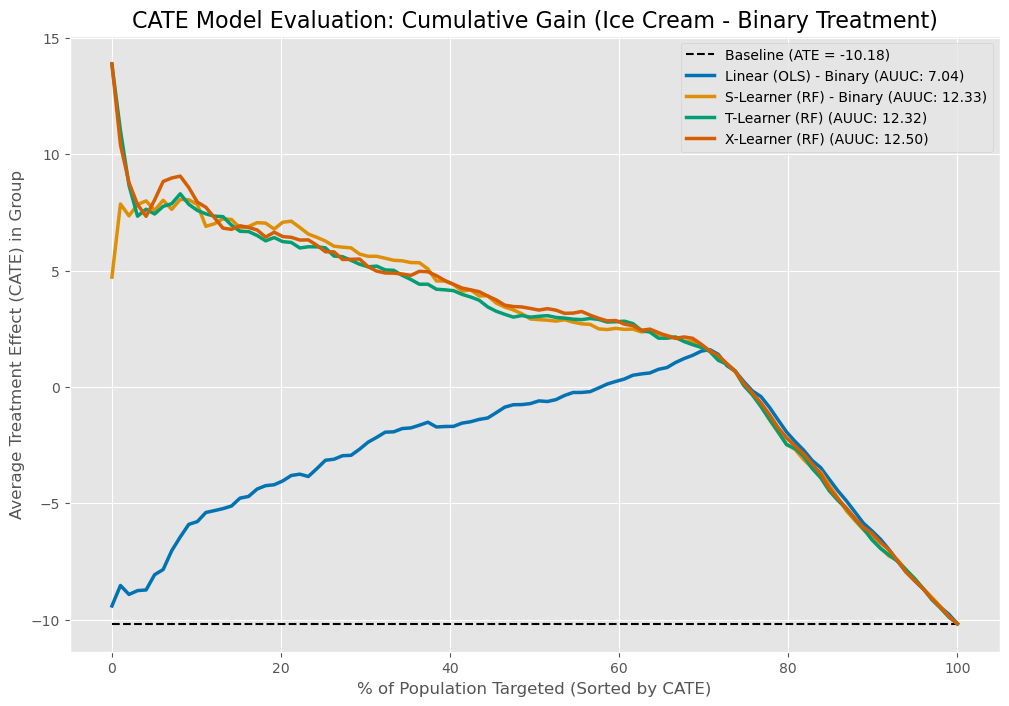

In [21]:
# ---  Part A-1: 이진 처치 기준 성능 비교 ---
models_ice_binary = {
    'Linear (OLS) - Binary': 'cate_linear_binary',
    'S-Learner (RF) - Binary': 'cate_s_learner_binary',
    'T-Learner (RF)': 'cate_t_learner',
    'X-Learner (RF)': 'cate_x_learner'
}
auuc_results_ice_binary = {}

for name, col in models_ice_binary.items():
    auuc = auuc_score_binary(test_preds_ice, col, Y_ice, T_ice_binary)
    auuc_results_ice_binary[name] = auuc

auuc_df_ice_binary = pd.DataFrame.from_dict(auuc_results_ice_binary, orient='index', 
                                            columns=['AUUC Score (IceCream - Binary)'])
print("--- 아이스크림 데이터 (이진 처치) AUUC 점수  ---")
print(auuc_df_ice_binary.sort_values('AUUC Score (IceCream - Binary)', ascending=False))

# ---  시각화 (Cumulative Gain Plot - 이진 처치 기준) ---
plt.figure(figsize=(12, 8))

baseline_ate_ice_binary = elast(test_preds_ice, Y_ice, T_ice_binary)
plt.plot([0, 100], [baseline_ate_ice_binary, baseline_ate_ice_binary], 'k--', 
         label=f'Baseline (ATE = {baseline_ate_ice_binary:.2f})')

for name, col in models_ice_binary.items():
    gain = cumulative_gain_binary(test_preds_ice, col, Y_ice, T_ice_binary)
    plt.plot(np.linspace(0, 100, len(gain)), gain, 
             label=f'{name} (AUUC: {auuc_results_ice_binary[name]:.2f})', 
             linewidth=2.5)

plt.title('CATE Model Evaluation: Cumulative Gain (Ice Cream - Binary Treatment)', fontsize=16)
plt.xlabel('% of Population Targeted (Sorted by CATE)')
plt.ylabel('Average Treatment Effect (CATE) in Group')
plt.legend()
plt.show()

비선형 메타-러너(S/T/X, AUUC: ~12.3)가 선형 OLS 모델(AUUC: 7.04)을 압도했습니다. 이 결과는 아이스크림 가격(처치)에 대한 반응(CATE)이 강한 비선형성을 띠고 있음을 명확히 보여줍니다. OLS는 "가격을 올려도 괜찮은" 그룹을 식별하지 못했지만, RF 기반 메타-러너들은 반응이 좋은 상위 그룹을 정확히 타겟팅했습니다.

### Part A-2: 아이스크림 데이터 (연속형 처치 T 비교)
목표: OLS(Cont)와 S-Learner(Cont) 2개 모델만 연속형 기준으로 비교 (기본 모델: RandomForestRegressor)

In [22]:
# --- 모델 1: 선형 CATE (OLS) - 연속형 T 기준 ---
formula_linear_ice_cont = 'sales ~ price * (temp + C(weekday) + cost)'
linear_model_ice_cont = smf.ols(formula_linear_ice_cont, data=train_ice).fit()

# CATE 추정 함수 (연속형 T용)
def get_linear_cate_predictions(model, df, t_col):
    df_t1 = df.copy(); df_t1[t_col] = df_t1[t_col] + 1
    return model.predict(df_t1) - model.predict(df)

test_preds_ice['cate_linear_cont'] = get_linear_cate_predictions(linear_model_ice_cont, test_preds_ice, T_ice_cont)

# --- 모델 2: S-Learner (RF) - 연속형 T 기준 ---
s_learner_ice_cont = clone(rf_model_base)
s_learner_ice_cont.fit(train_ice[X_ice + [T_ice_cont]], Y_train_ice)

# CATE 추정
X_test_s_ice_t1_cont = X_test_ice.copy(); X_test_s_ice_t1_cont[T_ice_cont] = test_ice[T_ice_cont] + 1
X_test_s_ice_t0_cont = X_test_ice.copy(); X_test_s_ice_t0_cont[T_ice_cont] = test_ice[T_ice_cont]
test_preds_ice['cate_s_learner_cont'] = s_learner_ice_cont.predict(X_test_s_ice_t1_cont) - s_learner_ice_cont.predict(X_test_s_ice_t0_cont)

--- 아이스크림 데이터 (연속 처치) AUUC 점수 ---
                        AUUC Score (IceCream - Continuous)
Linear (OLS) - Cont.                              0.867458
S-Learner (RF) - Cont.                           -0.109913


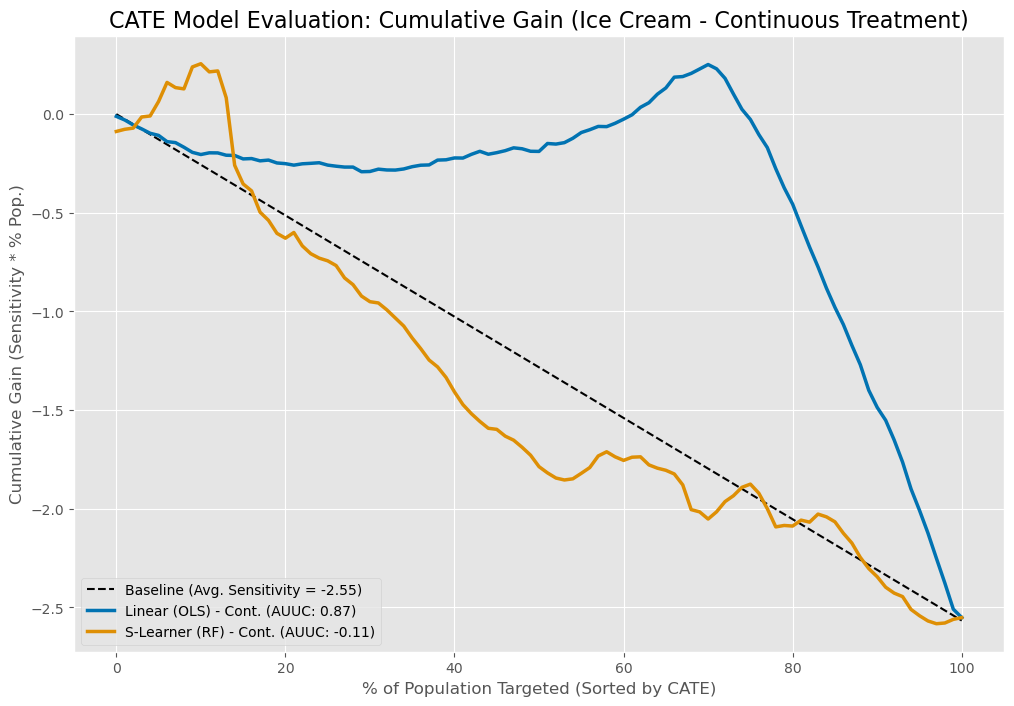

In [23]:
# --- Part A-2: 연속 처치(Continuous T) 기준 성능 비교 ---
models_ice_continuous = {
    'Linear (OLS) - Cont.': 'cate_linear_cont',
    'S-Learner (RF) - Cont.': 'cate_s_learner_cont'
}
auuc_results_ice_cont = {}

for name, col in models_ice_continuous.items():
    # 연속형 AUUC 헬퍼 함수 사용
    auuc = auuc_score_continuous(test_preds_ice, col, Y_ice, T_ice_cont) 
    auuc_results_ice_cont[name] = auuc

auuc_df_ice_cont = pd.DataFrame.from_dict(auuc_results_ice_cont, orient='index', 
                                          columns=['AUUC Score (IceCream - Continuous)'])
print("--- 아이스크림 데이터 (연속 처치) AUUC 점수 ---")
print(auuc_df_ice_cont.sort_values('AUUC Score (IceCream - Continuous)', ascending=False))

# --- 시각화 (Cumulative Gain Plot - 연속 처치 기준) ---
plt.figure(figsize=(12, 8))

baseline_sens_cont = sensitivity(test_preds_ice, Y_ice, T_ice_cont)
min_periods_cont = 30 
baseline_len = 100 
baseline_gain_cont = np.linspace(0, 1, baseline_len) * baseline_sens_cont * (len(test_preds_ice) / (len(test_preds_ice) - min_periods_cont + 1))

plt.plot(np.linspace(0, 100, len(baseline_gain_cont)), baseline_gain_cont, 'k--', 
         label=f'Baseline (Avg. Sensitivity = {baseline_sens_cont:.2f})')

for name, col in models_ice_continuous.items():
    # 연속형 Gain 헬퍼 함수 사용
    gain = cumulative_gain_continuous(test_preds_ice, col, Y_ice, T_ice_cont) 
    plt.plot(np.linspace(0, 100, len(gain)), gain, 
             label=f'{name} (AUUC: {auuc_results_ice_cont[name]:.2f})', 
             linewidth=2.5)

plt.title('CATE Model Evaluation: Cumulative Gain (Ice Cream - Continuous Treatment)', fontsize=16)
plt.xlabel('% of Population Targeted (Sorted by CATE)')
plt.ylabel('Cumulative Gain (Sensitivity * % Pop.)')
plt.legend()
plt.show()

선형 OLS 모델(AUUC: 0.87)이 S-Learner (RF) (AUUC: -0.11)보다 훨씬 우수했습니다. 이진 처치와 달리, CATE를 '연속적인 민감도(기울기)'로 추정하는 과제에서는 OLS가 더 뛰어났습니다. 이는 OLS가 처음부터 상호작용 항을 통해 이 기울기 자체를 추정하도록 설계되었기 때문입니다. 반면 S-Learner(RF)는 값(Y) 자체의 예측은 잘할 수 있어도, 그 '미분값(CATE)'을 안정적으로 추정하는 데는 구조적인 약점이 있음을 보여줍니다.

## 3. Part B: 이메일 마케팅 데이터 (이진형 T)
- 모든 모델은 편향된 train_email 데이터로 학습하고, 무작위 test_email 데이터로 평가합니다.
- 이메일 데이터셋(Part B)에 `LGBMRegressor`를 사용한 것은 원본 핸드북(21장)의 실험 환경을 정확하게 재현하기 위함입니다. `LGBM`은 `RandomForest`와 같은 트리 기반 모델이면서도, 더 빠르고 종종 더 나은 성능을 보여주어 CATE 추론을 위한 메타-러너의 기본 엔진으로 널리 사용됩니다. 메타-러너는 특정 ML 모델에 종속되지 않으므로 `RandomForest`를 기본 엔진으로 사용하는 것 역시 완벽하게 유효한 접근 방식입니다.

In [24]:
# --- 데이터 로드 및 변수 정의 ---
train_email = pd.read_csv("../data/matheus_data/invest_email_biased.csv")
test_email = pd.read_csv("../data/matheus_data/invest_email_rnd.csv")

Y_email = "converted"
T_email = "em1"
X_email = ["age", "income", "insurance", "invested"]

# 테스트 데이터 예측값 저장용
test_preds_email = test_email.copy()

# 학습/테스트 데이터 정의
X_train_em, Y_train_em = train_email[X_email], train_email[Y_email]
T_train_em = train_email[T_email]
X_test_em = test_email[X_email]

In [25]:
# --- 모델 1: 선형 CATE (OLS) ---
formula_linear_email = 'converted ~ em1 * (age + income + insurance + invested)'
linear_model_email = smf.ols(formula_linear_email, data=train_email).fit()

# CATE 추정
df_t1 = X_test_em.copy(); df_t1[T_email] = 1
df_t0 = X_test_em.copy(); df_t0[T_email] = 0
test_preds_email['cate_linear'] = linear_model_email.predict(df_t1) - linear_model_email.predict(df_t0)


# --- 모델 2: S-Learner (LGBM) ---
# 21장 S-Learner 파라미터 사용 (max_depth=3, min_child_samples=30)
s_learner_email = LGBMRegressor(max_depth=3, min_child_samples=30, random_state=42)
s_learner_email.fit(train_email[X_email + [T_email]], Y_train_em)

# CATE 추정
X_test_s_t1_em = X_test_em.copy(); X_test_s_t1_em[T_email] = 1
X_test_s_t0_em = X_test_em.copy(); X_test_s_t0_em[T_email] = 0
test_preds_email['cate_s_learner'] = s_learner_email.predict(X_test_s_t1_em) - s_learner_email.predict(X_test_s_t0_em)


# --- 모델 3: T-Learner (LGBM) ---
# 21장 T-Learner 파라미터 사용 (max_depth=2, min_child_samples=60)
t1_learner_email = LGBMRegressor(max_depth=2, min_child_samples=60, random_state=42)
t1_learner_email.fit(X_train_em[T_train_em == 1], Y_train_em[T_train_em == 1])

t0_learner_email = LGBMRegressor(max_depth=2, min_child_samples=60, random_state=42)
t0_learner_email.fit(X_train_em[T_train_em == 0], Y_train_em[T_train_em == 0])

test_preds_email['cate_t_learner'] = t1_learner_email.predict(X_test_em) - t0_learner_email.predict(X_test_em)


# --- 모델 4: X-Learner (LGBM) ---
# 1단계: 모델 3에서 학습한 t0_learner_email, t1_learner_email 사용
D_t1_em = Y_train_em[T_train_em == 1] - t0_learner_email.predict(X_train_em[T_train_em == 1])
D_t0_em = t1_learner_email.predict(X_train_em[T_train_em == 0]) - Y_train_em[T_train_em == 0]

# 2단계: 21장 X-Learner 2단계 파라미터 사용 (max_depth=2, min_child_samples=30)
x1_learner_email = LGBMRegressor(max_depth=2, min_child_samples=30, random_state=42)
x1_learner_email.fit(X_train_em[T_train_em == 1], D_t1_em)

x0_learner_email = LGBMRegressor(max_depth=2, min_child_samples=30, random_state=42)
x0_learner_email.fit(X_train_em[T_train_em == 0], D_t0_em)

# 성향 점수 모델 (penalty='none' 유지)
prop_model_email = LogisticRegression(random_state=42, solver='lbfgs', penalty=None, max_iter=1000)
prop_model_email.fit(X_train_em, T_train_em)

# CATE 추정
prop_scores_em = prop_model_email.predict_proba(X_test_em)[:, 1]
test_preds_email['cate_x_learner'] = (prop_scores_em * x0_learner_email.predict(X_test_em)) + \
                                     ((1 - prop_scores_em) * x1_learner_email.predict(X_test_em))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 996
[LightGBM] [Info] Number of data points in the train set: 15000, number of used features: 5
[LightGBM] [Info] Start training from score 0.200467
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

--- 이메일 데이터 AUUC 점수 (편향된 데이터로 학습) ---
                  AUUC Score (Email)
X-Learner (LGBM)            0.039434
S-Learner (LGBM)            0.035250
Linear (OLS)                0.033553
T-Learner (LGBM)            0.026654


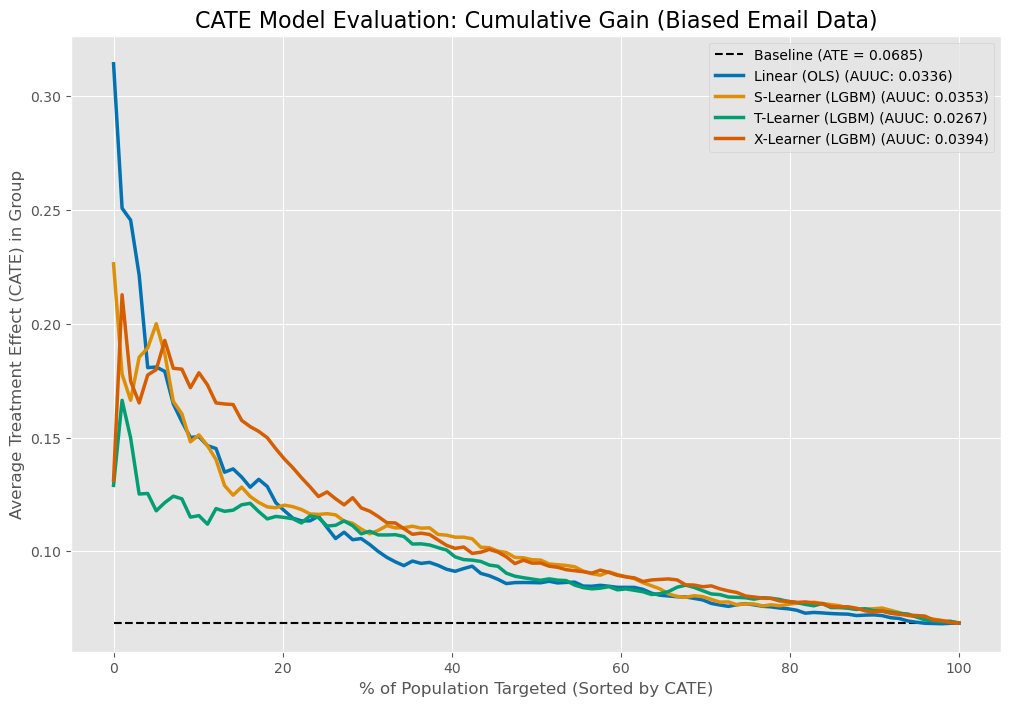

In [26]:
# --- 수치 비교 (AUUC) ---
models_email = {
    'Linear (OLS)': 'cate_linear',
    'S-Learner (LGBM)': 'cate_s_learner',
    'T-Learner (LGBM)': 'cate_t_learner',
    'X-Learner (LGBM)': 'cate_x_learner'
}
auuc_results_email = {}

for name, col in models_email.items():
    auuc = auuc_score_binary(test_preds_email, col, Y_email, T_email)
    auuc_results_email[name] = auuc

auuc_df_email = pd.DataFrame.from_dict(auuc_results_email, orient='index', columns=['AUUC Score (Email)'])
print("--- 이메일 데이터 AUUC 점수 (편향된 데이터로 학습) ---")
print(auuc_df_email.sort_values('AUUC Score (Email)', ascending=False))


# --- 시각화 (Cumulative Gain Plot) ---
plt.figure(figsize=(12, 8))

baseline_ate_email = elast(test_preds_email, Y_email, T_email)
plt.plot([0, 100], [baseline_ate_email, baseline_ate_email], 'k--', 
         label=f'Baseline (ATE = {baseline_ate_email:.4f})')

for name, col in models_email.items():
    gain = cumulative_gain_binary(test_preds_email, col, Y_email, T_email)
    plt.plot(np.linspace(0, 100, len(gain)), gain, 
             label=f'{name} (AUUC: {auuc_results_email[name]:.4f})', 
             linewidth=2.5)

plt.title('CATE Model Evaluation: Cumulative Gain (Biased Email Data)', fontsize=16)
plt.xlabel('% of Population Targeted (Sorted by CATE)')
plt.ylabel('Average Treatment Effect (CATE) in Group')
plt.legend()
plt.show()

모든 모델(OLS, S, T, X)이 베이스라인(ATE)보다 훨씬 우수한 성과를 보였으며, 그중 X-Learner(LGBM)가 가장 근소하게 우수했습니다 (AUUC: 0.0394).아이스크림 데이터와 달리, 이메일 데이터에서는 CATE의 이질성이 주로 선형적이거나 매우 단순할 가능성이 높습니다. OLS(AUUC: 0.0336)가 다른 메타-러너들과 거의 대등한 성능을 보인 것은, 복잡한 비선형 모델이 추가적으로 잡아낼 이질성이 거의 없었다는 의미입니다. 이는 OLS가 CATE 추론에서 강력한 기준선임을 재확인시켜 줍니다.

### 질문이나 의견을 남겨주세요.
<script src="https://utteranc.es/client.js"
        repo="CausalInferenceLab/awesome-causal-inference-python"
        issue-term="pathname"
        theme="github-light"
        crossorigin="anonymous"
        async>
</script>